# Lab 1 (SOLUTION) — Simulate Potential Outcomes and Selection Bias
# المختبر 1 — محاكاة النواتج المحتملة وتحيّز الاختيار

**Module 1 · الوحدة 1 — Causal Thinking and Potential Outcomes / التفكير السببي والنواتج المحتملة**
SDA-DSC-213 · Experimentation, A/B Testing and Causal Inference · SDAIA Academy

---

### The decision on the table

Injaz (إنجاز) is piloting a **guided document uploader**. During the soft launch,
users could *opt in*. The dashboard says opt-in users complete services **19 points**
more often than everyone else. A director wants to spend the national rollout budget
on that number.

Your job in the next 50 minutes is to prove — in a world where you can *see* the
right answer — that this 19 points is mostly **selection bias (تحيّز الاختيار)**, and
that a coin flip would have given the honest number.

### What you will build

| # | Step | Minutes |
|---|---|---|
| 1 | A simulator with **both** potential outcomes and a planted ground-truth effect | 8 |
| 2 | Two assignment mechanisms — self-selection and randomisation — plus the reveal rule | 10 |
| 3 | The naive difference-in-means under each mechanism | 10 |
| 4 | The selection-bias term computed *directly*, and the identity naive = ATT + bias | 10 |
| 5 | The sample-size sweep that kills the "we have millions of rows" defence | 7 |
| 6 | A three-sentence conclusion a non-technical director can read | 5 |

### The vocabulary this lab installs (bilingual, once)

- **potential outcomes (النواتج المحتملة)** — Y(1) and Y(0): the two outcomes the same
  unit would have with and without treatment.
- **counterfactual (النتيجة المضادة للواقع)** — the one of those two you did *not* observe.
- **ATE (متوسط أثر المعالجة)** — E[Y(1) − Y(0)] over everyone.
- **ATT (متوسط أثر المعالجة على المُعالَجين)** — E[Y(1) − Y(0) | T = 1], the effect among
  those who actually got it.
- **selection bias (تحيّز الاختيار)** — E[Y(0)|T=1] − E[Y(0)|T=0]: how different the two
  groups would have been *with no treatment at all*.
- **confounder (المتغيّر المُربِك)** — here, digital literacy: it raises both opt-in and completion.

> All code, variables and comments stay in **English**. Only the concepts are bilingual.


---
## Step 0 — Environment and the numbers we are aiming at

`causal_utils` is the course toolkit you are assembling across Labs 1–7. Lab 1
contributes the **simulator and the bias decomposition** — the ground-truth harness
every later method gets checked against.

`GROUND_TRUTH.json` holds the numbers that were *deliberately planted* in the course
datasets. Read it now, so that at the end of the lab you are comparing against a
target you did not choose after the fact.


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Make `causal_utils` importable from anywhere under course_assets/
ROOT = Path.cwd()
while not (ROOT / "causal_utils").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from causal_utils import use_sdaia_style
use_sdaia_style()

RANDOM_SEED = 213          # fixed for every lab: reproducibility is graded
rng = np.random.default_rng(RANDOM_SEED)
print("Environment ready ·", ROOT)

Environment ready · /home/claude/course_assets


In [2]:
def needs(*values, msg="complete the TODO in the cell above, then re-run this cell"):
    """Guard for the start notebook: True (with a friendly note) if a TODO is unfinished.

    This is why the start notebook runs top-to-bottom without a traceback even
    before you have written a line of code.
    """
    if any(v is None for v in values):
        print(f"[not implemented yet] {msg}")
        return True
    return False


def sigmoid(x):
    """Logistic function — turns a real-valued index into a probability."""
    return 1.0 / (1.0 + np.exp(-x))

In [3]:
import json

with open(DATA / "GROUND_TRUTH.json") as f:
    GROUND_TRUTH = json.load(f)

M1 = GROUND_TRUTH["module1_potential_outcomes"]
print("Planted ground truth for Module 1")
print(f"  true ATE                    : {M1['true_ATE']:+.4f}   ({100*M1['true_ATE']:+.2f} pp)")
print(f"  naive, self-selected groups : {M1['naive_self_selected']:+.4f}   ({100*M1['naive_self_selected']:+.2f} pp)")
print(f"  naive, randomised groups    : {M1['naive_randomised']:+.4f}   ({100*M1['naive_randomised']:+.2f} pp)")
print(f"  selection-bias term         : {M1['selection_bias_term']:+.4f}   ({100*M1['selection_bias_term']:+.2f} pp)")

Planted ground truth for Module 1
  true ATE                    : +0.0504   (+5.04 pp)
  naive, self-selected groups : +0.1930   (+19.30 pp)
  naive, randomised groups    : +0.0504   (+5.04 pp)
  selection-bias term         : +0.1432   (+14.32 pp)


---
## Step 1 *(8 min)* — Build the simulator

The whole course rests on one teaching device: **plant an effect you can see, then
check which estimator recovers it.** In reality Y(1) and Y(0) never both exist for
the same person — that is the *fundamental problem of causal inference*. In a
simulator they do, which is the only place you can grade an estimator honestly.

The data-generating process, deliberately simple:

```
literacy_i  ~ Beta(2, 2)                     # latent digital literacy, mean 0.5
p0_i        = 0.55 + beta_literacy * (literacy_i - 0.5) + 0.09 * user_effect_i
p1_i        = p0_i + true_effect             # the treatment adds a constant on the probability scale
y0_i        = 1{u_i < p0_i},  y1_i = 1{u_i < p1_i}     # SAME u_i -> coupled potential outcomes
p_optin_i   = sigmoid(k_select * (literacy_i - 0.5))   # literacy drives who opts in
```

Two design choices worth pausing on:

1. **`literacy` enters both `p0` and `p_optin`.** That is exactly what makes it a
   *confounder*: it lifts completion whether or not you treat, and it lifts adoption.
2. **`y0` and `y1` share the same uniform draw `u_i`.** Without that coupling the
   individual effect `tau_i` would be mostly draw noise. Coupling gives a clean
   monotone treatment: nobody is hurt by the uploader.


In [4]:
def simulate_injaz_users(n=20_000, true_effect=0.05, beta_literacy=1.3284,
                         k_select=2.5, seed=RANDOM_SEED):
    """Simulate Injaz users where BOTH potential outcomes are known.

    Parameters
    ----------
    n             : number of users.
    true_effect   : the planted ATE on the completion PROBABILITY (0.05 = +5 pp).
    beta_literacy : how strongly digital literacy raises baseline completion
                    (the confounding path literacy -> completion).
    k_select      : how strongly digital literacy raises opt-in
                    (the confounding path literacy -> treatment).
    seed          : reproducibility. Every number in this course is re-runnable.

    Returns a DataFrame with y0, y1, tau_i and the two assignment propensities.
    """
    g = np.random.default_rng(seed)

    literacy = g.beta(2, 2, size=n)              # latent skill, mean 0.5
    lit_c = literacy - 0.5                       # centred, so 0.55 stays the mean baseline
    user_effect = g.normal(0, 1, size=n)         # habit / motivation we never measure

    # Y(0): probability of completing WITHOUT the guided uploader
    p0 = np.clip(0.55 + beta_literacy * lit_c + 0.09 * user_effect, 0.04, 0.95)
    # Y(1): the uploader adds `true_effect` on the probability scale
    p1 = np.clip(p0 + true_effect, 0.04, 0.99)

    # ONE uniform draw per user -> coupled potential outcomes, no gratuitous noise
    u = g.random(n)
    y0 = (u < p0).astype(int)
    y1 = (u < p1).astype(int)

    p_optin = sigmoid(k_select * lit_c)          # the selection mechanism

    return pd.DataFrame({
        "digital_literacy": literacy,
        "user_effect": user_effect,
        "p0": p0, "p1": p1,
        "y0": y0, "y1": y1,
        "tau_i": y1 - y0,                        # REAL here, UNOBSERVABLE in the wild
        "p_optin": p_optin,
    })


users = simulate_injaz_users()
true_ate = users["tau_i"].mean()
print(f"n                          : {len(users):,}")
print(f"True ATE (planted, realised): {true_ate:+.4f}  ({100*true_ate:+.2f} pp)")
print(f"Baseline completion  E[Y(0)]: {users['y0'].mean():.4f}")
lo, hi = users["digital_literacy"].quantile([0.1, 0.9])
print(f"P(opt in) bottom-decile literacy: {users.loc[users.digital_literacy <= lo, 'p_optin'].mean():.3f}")
print(f"P(opt in) top-decile literacy   : {users.loc[users.digital_literacy >= hi, 'p_optin'].mean():.3f}")
print("The confounder is wired in: literate users are far likelier to adopt the feature.")

n                          : 20,000
True ATE (planted, realised): +0.0463  (+4.63 pp)
Baseline completion  E[Y(0)]: 0.5447
P(opt in) bottom-decile literacy: 0.285
P(opt in) top-decile literacy   : 0.716
The confounder is wired in: literate users are far likelier to adopt the feature.


> ### Instructor note — Step 1
>
> **Teaching point.** The realised ATE prints at about **+4.6 pp**, not exactly +5.0 pp,
> because `p0` is clipped at 0.95: for the most literate users there is no room to add
> five points. Say this out loud — it is the first lesson that a *planted* number and a
> *realised* number are different things, and that you always report the realised one.
>
> **Common wrong answer.** Drawing `y0` and `y1` from two independent `binomial` calls.
> The ATE still comes out right, but `tau_i` becomes ±1 noise for most users and the
> "individual effect" story collapses. If someone's `tau_i` has lots of −1s, this is why.
>
> **When a participant is stuck.** Ask them to print `users[["p0","p1","y0","y1"]].head(10)`
> and find a row where `p0 < u < p1`. That row is the person the uploader actually helped.
> Everyone else was going to complete anyway, or was never going to.

---
## Step 2 *(10 min)* — Two assignment mechanisms, one reveal rule

Same users. Same true effect. **Only the assignment mechanism differs.**

- **Self-selection:** `T_self ~ Bernoulli(p_optin)` — literate users opt in more.
- **Randomisation:** `T_rand ~ Bernoulli(0.5)` — a coin flip, independent of everything.

Then the *consistency* rule links potential outcomes to what you actually observe:

$$Y_i = T_i\,Y_i(1) + (1 - T_i)\,Y_i(0)$$

In code that is `np.where(T == 1, y1, y0)`. Get this backwards and your estimate
flips sign — which is exactly the debugging exercise at the end of this lab.


In [5]:
def assign_self_selection(df, seed=RANDOM_SEED + 1):
    """Opt-in assignment: P(T=1) rises with digital literacy. This is CONFOUNDED."""
    g = np.random.default_rng(seed)
    return (g.random(len(df)) < df["p_optin"].to_numpy()).astype(int)


def assign_randomised(df, share=0.5, seed=RANDOM_SEED + 2):
    """Coin-flip assignment: P(T=1) is a constant, independent of everything."""
    g = np.random.default_rng(seed)
    return (g.random(len(df)) < share).astype(int)


def reveal_observed(df, t_col):
    """Consistency: Y = T*Y(1) + (1-T)*Y(0). Exactly one potential outcome survives."""
    return np.where(df[t_col].to_numpy() == 1, df["y1"].to_numpy(), df["y0"].to_numpy())


users["T_self"] = assign_self_selection(users)
users["T_rand"] = assign_randomised(users)
users["y_self"] = reveal_observed(users, "T_self")
users["y_rand"] = reveal_observed(users, "T_rand")

print(f"treated share, self-selection : {users['T_self'].mean():.3f}")
print(f"treated share, randomisation  : {users['T_rand'].mean():.3f}")
print()
print("Mean literacy by arm — the fingerprint of confounding:")
print(f"  self-selected  treated {users.loc[users.T_self == 1, 'digital_literacy'].mean():.3f}"
      f"   control {users.loc[users.T_self == 0, 'digital_literacy'].mean():.3f}")
print(f"  randomised     treated {users.loc[users.T_rand == 1, 'digital_literacy'].mean():.3f}"
      f"   control {users.loc[users.T_rand == 0, 'digital_literacy'].mean():.3f}")

treated share, self-selection : 0.498
treated share, randomisation  : 0.498

Mean literacy by arm — the fingerprint of confounding:
  self-selected  treated 0.557   control 0.440
  randomised     treated 0.497   control 0.500


> ### Instructor note — Step 2
>
> **Teaching point.** Both mechanisms treat about half the users. The *share* is
> identical; the *composition* is not. Put the two literacy rows on the board:
> self-selection treated ≈ 0.56 vs control ≈ 0.44, randomisation ≈ 0.50 vs 0.50.
> That single comparison is the whole module.
>
> **Common wrong answer.** `reveal_observed` written as `np.where(T == 1, y0, y1)`.
> Under randomisation the estimate comes out around **−0.04**, and under self-selection
> around **+0.09**. Someone will say "the uploader hurts users."
> Let them say it, then ask which world they revealed.
>
> **When a participant is stuck.** Tell them to forget statistics for a second:
> "You have two columns. A person got the treatment. Which column is the one you
> would actually see in the database?" 

### ✅ Checkpoint A — what you should be seeing by now

Run the cell below. If it prints all three ticks you are on pace (≈18 minutes in).


In [6]:
def checkpoint_a():
    ok = True
    if users is None or "y_self" not in users.columns:
        print("✗ Steps 1-2 incomplete — the simulator or the reveal rule is still a TODO.")
        return
    print(f"✓ simulator built           : {len(users):,} users, both Y(0) and Y(1) present")
    print(f"✓ planted ATE recovered     : {users['tau_i'].mean():+.4f}  (target ≈ +0.05)")
    lit_gap = (users.loc[users.T_self == 1, "digital_literacy"].mean()
               - users.loc[users.T_self == 0, "digital_literacy"].mean())
    print(f"✓ confounding is present    : literacy gap {lit_gap:+.3f} under self-selection, "
          f"{users.loc[users.T_rand == 1, 'digital_literacy'].mean() - users.loc[users.T_rand == 0, 'digital_literacy'].mean():+.3f} under randomisation")
    print()
    print("Next: the naive difference under each mechanism, and why they disagree.")

checkpoint_a()

✓ simulator built           : 20,000 users, both Y(0) and Y(1) present
✓ planted ATE recovered     : +0.0463  (target ≈ +0.05)
✓ confounding is present    : literacy gap +0.117 under self-selection, -0.003 under randomisation

Next: the naive difference under each mechanism, and why they disagree.


---
## Step 3 *(10 min)* — The naive difference under each mechanism

The estimator every dashboard in the world computes:

$$\hat\tau_{\text{naive}} = \bar{Y}_{T=1} - \bar{Y}_{T=0}$$

Run it on both mechanisms. The true effect is **identical** in the two columns — the
only thing that changed is *who* got treated.


In [7]:
def naive_diff(df, t_col, y_col):
    """Difference in observed group means — the estimator on every dashboard."""
    y = df[y_col].to_numpy()
    t = df[t_col].to_numpy()
    return float(y[t == 1].mean() - y[t == 0].mean())


est_self = naive_diff(users, "T_self", "y_self")
est_rand = naive_diff(users, "T_rand", "y_rand")

print(f"True ATE (we can see it)   : {true_ate:+.4f}   ({100*true_ate:+.2f} pp)")
print(f"Naive, self-selected groups: {est_self:+.4f}   ({100*est_self:+.2f} pp)  <- biased HIGH")
print(f"Naive, randomised groups   : {est_rand:+.4f}   ({100*est_rand:+.2f} pp)  <- ~unbiased")
print()
print(f"Self-selection overstates the effect by a factor of {est_self / true_ate:.1f}x.")

True ATE (we can see it)   : +0.0463   (+4.63 pp)
Naive, self-selected groups: +0.1865   (+18.65 pp)  <- biased HIGH
Naive, randomised groups   : +0.0505   (+5.05 pp)  <- ~unbiased

Self-selection overstates the effect by a factor of 4.0x.


> ### Instructor note — Step 3

> **Teaching point.** Say the numbers slowly: **+18.7 pp** self-selected, **+5.1 pp**
> randomised, on the *same 20,000 people with the same planted effect*. Nothing about the
> world changed between those two lines — only who was put in which group. That is the
> entire content of "randomisation identifies the ATE", and it lands better as two printed
> numbers than as a proof.
>
> **Common wrong answer.** "The randomised estimate is lower because randomisation somehow
> weakens the treatment." Kill this immediately: the treatment is identical in both columns
> (`y1` is the same array). The self-selected number is not a bigger effect, it is a
> different quantity — ATT plus a gap that has nothing to do with the uploader.
>
> **When a participant is stuck.** Ask them to compute mean literacy in each arm under each
> mechanism (they printed it in Step 2). 0.56 vs 0.44 under opt-in, 0.50 vs 0.50 under the
> coin flip. Then ask: "which of those two comparisons is comparing like with like?"


**Answer.**

The two numbers differ because the *comparison groups* differ, not because the effect
differs. Under self-selection the treated group is made of high-literacy users who
would have completed at a much higher rate **even with no uploader at all**; the
difference in means therefore measures the uploader *plus* the pre-existing gap
between the groups. Under randomisation the two groups are exchangeable by
construction, so the pre-existing gap is zero in expectation and the difference in
means measures the uploader alone.


---
## Step 4 *(10 min)* — Decompose the naive difference

The algebra derived on the whiteboard:

$$\underbrace{E[Y|T{=}1] - E[Y|T{=}0]}_{\text{naive}} \;=\; \underbrace{E[Y(1)-Y(0)\mid T{=}1]}_{\textbf{ATT}} \;+\; \underbrace{E[Y(0)\mid T{=}1] - E[Y(0)\mid T{=}0]}_{\textbf{selection bias}}$$

In real data the second term is **unmeasurable** — you never see Y(0) for treated
units. In this simulator you do. Compute it directly and confirm the identity holds
to the fourth decimal.


In [8]:
def decompose(df, t_col, y_col):
    """Split the naive difference into ATT + selection bias.

    Only possible because the simulator exposes Y(0) for EVERYONE, including the
    users who were treated. That column does not exist in any real dataset.
    """
    t = df[t_col].to_numpy()
    att = float(df.loc[t == 1, "tau_i"].mean())
    bias = float(df.loc[t == 1, "y0"].mean() - df.loc[t == 0, "y0"].mean())
    naive = naive_diff(df, t_col, y_col)
    return {"mechanism": t_col, "naive": naive, "ATT": att,
            "selection_bias": bias, "ATT_plus_bias": att + bias,
            "identity_gap": naive - (att + bias)}


decomp = pd.DataFrame([decompose(users, "T_self", "y_self"),
                       decompose(users, "T_rand", "y_rand")])
print(decomp.round(4).to_string(index=False))
print()
print("The identity holds exactly: naive = ATT + selection bias, by construction.")
print(f"Under self-selection the bias term is {100*decomp.loc[0, 'selection_bias']:+.2f} pp —")
print(f"that is {100*decomp.loc[0, 'selection_bias'] / decomp.loc[0, 'naive']:.0f}% of the headline number.")

mechanism  naive    ATT  selection_bias  ATT_plus_bias  identity_gap
   T_self 0.1865 0.0471          0.1393         0.1865           0.0
   T_rand 0.0505 0.0458          0.0047         0.0505           0.0

The identity holds exactly: naive = ATT + selection bias, by construction.
Under self-selection the bias term is +13.93 pp —
that is 75% of the headline number.


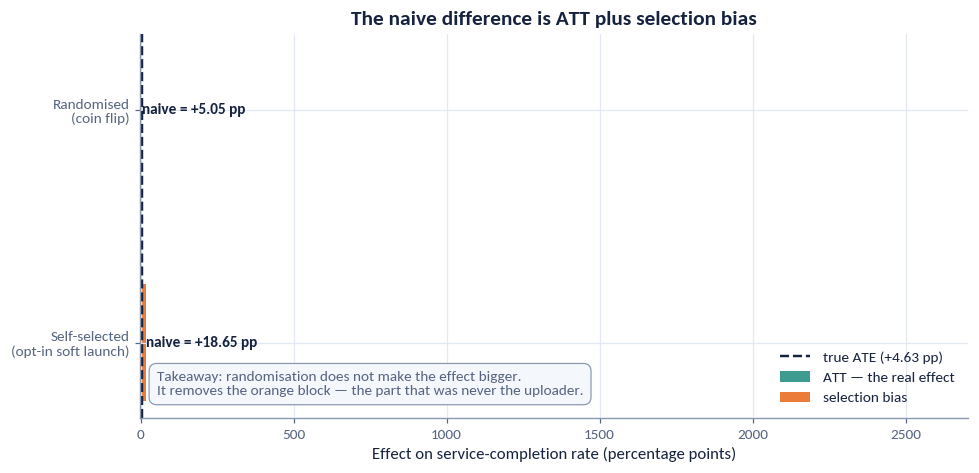

In [9]:
from causal_utils import NAVY, BLUE, ORANGE, TEAL, SLATE, MUTED

def plot_decomposition(decomp):
    fig, ax = plt.subplots(figsize=(9, 4.4))
    labels = ["Self-selected\n(opt-in soft launch)", "Randomised\n(coin flip)"]
    att = 100 * decomp["ATT"].to_numpy()
    bias = 100 * decomp["selection_bias"].to_numpy()

    ax.barh(labels, att, color=TEAL, label="ATT — the real effect", height=0.5)
    ax.barh(labels, bias, left=att, color=ORANGE, label="selection bias", height=0.5)
    ax.axvline(100 * true_ate, color=NAVY, ls="--", lw=1.6,
               label=f"true ATE ({100*true_ate:+.2f} pp)")

    for i, (a, b) in enumerate(zip(att, bias)):
        ax.text(a + b + 0.4, i, f"naive = {a + b:+.2f} pp", va="center",
                fontsize=10, color=NAVY, fontweight="bold")

    ax.set_xlabel("Effect on service-completion rate (percentage points)")
    ax.set_title("The naive difference is ATT plus selection bias")
    ax.legend(loc="lower right")
    ax.set_xlim(-1, 100 * (att + bias).max() * 1.45)
    ax.annotate(
        "Takeaway: randomisation does not make the effect bigger.\n"
        "It removes the orange block — the part that was never the uploader.",
        xy=(0.02, 0.06), xycoords="axes fraction", fontsize=10, color=SLATE,
        bbox=dict(boxstyle="round,pad=0.5", fc="#F4F7FB", ec=MUTED, lw=0.8))
    plt.tight_layout()
    plt.show()


plot_decomposition(decomp)

> ### Instructor note — Step 4
>
> **Teaching point.** The bias term lands at about **+13.9 pp** — roughly **three
> quarters** of the 19-point headline. Say the sentence explicitly: *"three quarters of
> the number in the director's deck is not the uploader."* That is the line participants
> repeat back to stakeholders next month.
>
> **Common wrong answer.** Computing the bias as `mean(y_self | T=1) - mean(y_self | T=0)`
> — i.e. from the *observed* column instead of `y0`. That just recomputes the naive
> difference and the identity gap comes out as `-ATT`. The bias term must use `y0` for
> **both** groups, including treated units, which is precisely the column reality denies you.
>
> **When a participant is stuck.** Draw the 2×2 on the board: rows = groups, columns =
> Y(0) and Y(1). Circle the two cells the bias term needs and point out that one of them
> is greyed out in every real dataset.

### ✅ Checkpoint B — what you should be seeing by now

≈38 minutes in. You should have a table where the self-selection row reads roughly
`naive +0.19 = ATT +0.05 + bias +0.14` and the randomised row reads
`naive +0.05 = ATT +0.05 + bias +0.00`.


In [10]:
def checkpoint_b():
    if decomp is None:
        print("✗ Step 4 incomplete — the decomposition is still a TODO.")
        return
    s = decomp.set_index("mechanism")
    print(f"✓ naive, self-selected : {s.loc['T_self', 'naive']:+.4f}   (target ≈ +0.19)")
    print(f"✓ naive, randomised    : {s.loc['T_rand', 'naive']:+.4f}   (target ≈ +0.05)")
    print(f"✓ bias, self-selected  : {s.loc['T_self', 'selection_bias']:+.4f}   (target ≈ +0.14)")
    print(f"✓ bias, randomised     : {s.loc['T_rand', 'selection_bias']:+.4f}   (target ≈  0.00)")
    print("\nNext: the sample-size sweep — the part that changes how you argue with stakeholders.")

checkpoint_b()

✓ naive, self-selected : +0.1865   (target ≈ +0.19)
✓ naive, randomised    : +0.0505   (target ≈ +0.05)
✓ bias, self-selected  : +0.1393   (target ≈ +0.14)
✓ bias, randomised     : +0.0047   (target ≈  0.00)

Next: the sample-size sweep — the part that changes how you argue with stakeholders.


---
## Step 5 *(7 min)* — Bias does not shrink with data

The most expensive misconception in applied data science: *"we have four million rows,
so the result must be reliable."*

More data shrinks **variance**. It does nothing at all to **bias**. Sweep
n ∈ {1k, 10k, 100k, 1M}, five independent replicates each, and watch the two curves
converge — to two different numbers.


In [11]:
def sweep_sample_size(sizes=(1_000, 10_000, 100_000, 1_000_000), n_reps=5):
    """Re-run the whole simulation at several sample sizes and record both estimates."""
    rows = []
    for n in sizes:
        for rep in range(n_reps):
            d = simulate_injaz_users(n=n, seed=1_000 + rep)
            d["T_self"] = assign_self_selection(d, seed=2_000 + rep)
            d["T_rand"] = assign_randomised(d, seed=3_000 + rep)
            d["y_self"] = reveal_observed(d, "T_self")
            d["y_rand"] = reveal_observed(d, "T_rand")
            rows.append({"n": n, "rep": rep,
                         "self_selected": naive_diff(d, "T_self", "y_self"),
                         "randomised": naive_diff(d, "T_rand", "y_rand"),
                         "true_ate": d["tau_i"].mean()})
    return pd.DataFrame(rows)


sweep = sweep_sample_size()
summary = sweep.groupby("n")[["self_selected", "randomised", "true_ate"]].agg(["mean", "std"])
print(summary.round(4).to_string())

        self_selected         randomised         true_ate        
                 mean     std       mean     std     mean     std
n                                                                
1000           0.1932  0.0303     0.0516  0.0315   0.0494  0.0036
10000          0.1859  0.0115     0.0500  0.0033   0.0488  0.0008
100000         0.1927  0.0023     0.0494  0.0022   0.0491  0.0004
1000000        0.1915  0.0008     0.0478  0.0013   0.0488  0.0002


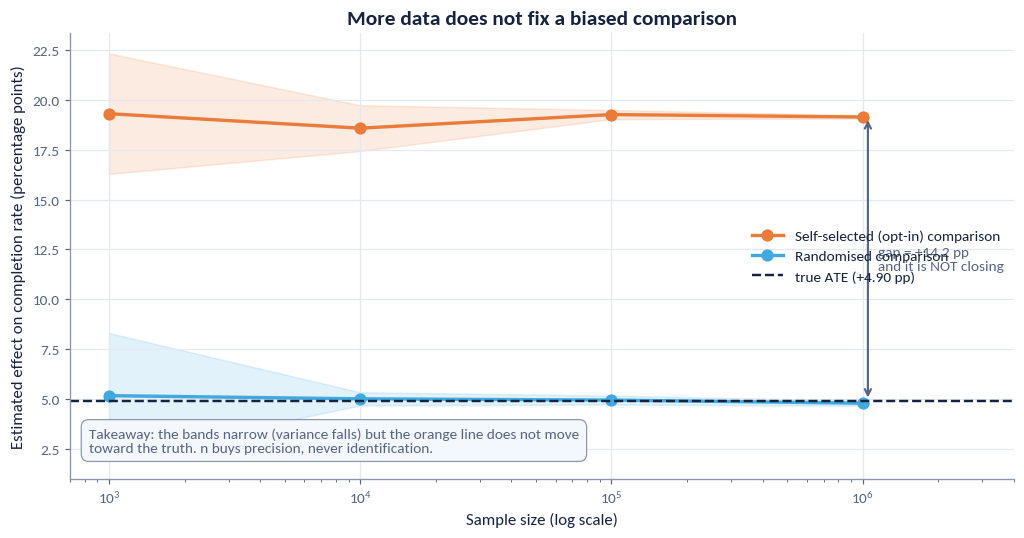

In [12]:
def plot_convergence(sweep):
    agg = sweep.groupby("n").agg(
        self_mean=("self_selected", "mean"), self_sd=("self_selected", "std"),
        rand_mean=("randomised", "mean"), rand_sd=("randomised", "std"),
        truth=("true_ate", "mean")).reset_index()

    fig, ax = plt.subplots(figsize=(9.5, 5))
    x = agg["n"]
    for col_m, col_s, colour, label in [
            ("self_mean", "self_sd", ORANGE, "Self-selected (opt-in) comparison"),
            ("rand_mean", "rand_sd", BLUE, "Randomised comparison")]:
        ax.plot(x, 100 * agg[col_m], "o-", color=colour, lw=2.2, ms=7, label=label)
        ax.fill_between(x, 100 * (agg[col_m] - agg[col_s]), 100 * (agg[col_m] + agg[col_s]),
                        color=colour, alpha=0.15)
    ax.axhline(100 * agg["truth"].mean(), color=NAVY, ls="--", lw=1.6,
               label=f"true ATE ({100*agg['truth'].mean():+.2f} pp)")

    ax.set_xscale("log")
    ax.set_xlabel("Sample size (log scale)")
    ax.set_ylabel("Estimated effect on completion rate (percentage points)")
    ax.set_title("More data does not fix a biased comparison")
    ax.legend(loc="center right")

    gap = 100 * (agg["self_mean"].iloc[-1] - agg["truth"].mean())
    ax.annotate("", xy=(1.05e6, 100 * agg["self_mean"].iloc[-1]),
                xytext=(1.05e6, 100 * agg["truth"].mean()),
                arrowprops=dict(arrowstyle="<->", color=SLATE, lw=1.4))
    ax.text(1.15e6, 100 * (agg["self_mean"].iloc[-1] + agg["truth"].mean()) / 2,
            f"gap = {gap:+.1f} pp\nand it is NOT closing", va="center",
            fontsize=10, color=SLATE)
    ax.set_xlim(700, 4e6)
    ax.annotate(
        "Takeaway: the bands narrow (variance falls) but the orange line does not move\n"
        "toward the truth. n buys precision, never identification.",
        xy=(0.02, 0.06), xycoords="axes fraction", fontsize=10, color=SLATE,
        bbox=dict(boxstyle="round,pad=0.5", fc="#F4F7FB", ec=MUTED, lw=0.8))
    plt.tight_layout()
    plt.show()


plot_convergence(sweep)

> ### Instructor note — Step 5
>
> **Teaching point.** This plot is the emotional core of Module 1. Do not narrate it —
> put it up and stay quiet for ten seconds. The orange band gets *tighter* around the
> wrong answer. A confident wrong number is more dangerous than a noisy right one.
>
> **Common wrong answer.** "So we just need a bigger sample and a confidence interval."
> Press on it: at n = 1M the self-selected 95% interval is roughly ±0.15 pp wide and
> excludes the truth by 14 pp. The interval is *correct* about the quantity it estimates
> — that quantity is simply not the causal effect.
>
> **When a participant is stuck.** The sweep is slow if they re-simulate inside the plot
> function. One `simulate_injaz_users(n=1_000_000)` call takes about a second; five
> replicates is fine, fifty is not. Tell them to keep `n_reps` at 5.

---
## Step 6 — Two extras that pay off later

**(a) The confounding dial.** Bias magnitude is set by *confounding strength*, not by n.
Sweep `k_select` (how strongly literacy drives opt-in) and watch only the orange line move.

**(b) Adjusting for the confounder.** If you *measured* the confounder you can regress it
away. Here literacy is fully observed, so adjustment nearly recovers the truth — which is
the whole promise, and the whole fragility, of Modules 5 and 6: it works only for the
confounders you named and measured.


In [13]:
# (a) confounding dial ---------------------------------------------------
dial = []
for k in [0.0, 1.0, 2.0, 2.5, 4.0, 6.0]:
    d = simulate_injaz_users(n=100_000, k_select=k, seed=7)
    d["T_self"] = assign_self_selection(d, seed=11)
    d["T_rand"] = assign_randomised(d, seed=12)
    d["y_self"] = reveal_observed(d, "T_self")
    d["y_rand"] = reveal_observed(d, "T_rand")
    dial.append({"k_select": k,
                 "self_selected": naive_diff(d, "T_self", "y_self"),
                 "randomised": naive_diff(d, "T_rand", "y_rand")})
dial = pd.DataFrame(dial)
print("(a) Confounding dial — n is fixed at 100,000 for every row\n")
print(dial.round(4).to_string(index=False))

# (b) covariate adjustment -----------------------------------------------
import statsmodels.formula.api as smf

big = simulate_injaz_users(n=100_000, seed=RANDOM_SEED)
big["T_self"] = assign_self_selection(big, seed=RANDOM_SEED + 1)
big["y"] = reveal_observed(big, "T_self")
m_naive = smf.ols("y ~ T_self", data=big).fit(cov_type="HC3")
m_adj = smf.ols("y ~ T_self + digital_literacy", data=big).fit(cov_type="HC3")
print("\n(b) Adjusting for the measured confounder\n")
print(f"  naive OLS               : {m_naive.params['T_self']:+.4f}")
print(f"  + digital_literacy      : {m_adj.params['T_self']:+.4f}")
print(f"  true ATE                : {big['tau_i'].mean():+.4f}")
print("\n  Adjustment works here ONLY because literacy is the sole confounder and we")
print("  measured it perfectly. Modules 5-6 are about what to do when neither holds.")

(a) Confounding dial — n is fixed at 100,000 for every row

 k_select  self_selected  randomised
      0.0         0.0495      0.0448
      1.0         0.1072      0.0448
      2.0         0.1641      0.0448
      2.5         0.1903      0.0448
      4.0         0.2616      0.0448
      6.0         0.3327      0.0448

(b) Adjusting for the measured confounder

  naive OLS               : +0.1968
  + digital_literacy      : +0.0522
  true ATE                : +0.0486

  Adjustment works here ONLY because literacy is the sole confounder and we
  measured it perfectly. Modules 5-6 are about what to do when neither holds.


> ### Instructor note — Step 6

> **Teaching point (a).** The dial is the answer to "how big is the bias?" — it is set by
> **confounding strength**, not by sample size. At `k_select = 0` (opt-in unrelated to
> literacy) the self-selected estimate sits on the truth; at `k_select = 6` it is seven
> times the truth. n was fixed at 100,000 for every row.
>
> **Teaching point (b).** Adjustment takes the estimate from **+0.196 to +0.054** — almost
> the whole way home. Do not let the room leave thinking this is a general result. It works
> here for two reasons that essentially never hold in the wild: literacy is the *only*
> confounder, and we measured it *perfectly*. Modules 5 and 6 are entirely about what
> happens when either assumption breaks.
>
> **Common wrong answer.** "So we can always just control for the confounder." Ask what
> they would have controlled for if the simulator had also included an unmeasured
> motivation variable. Randomisation balances the confounders you never thought of; a
> regression cannot.
>
> **When a participant is stuck.** If their dial shows the *randomised* line moving with
> `k_select`, they reused a stale assignment column instead of re-assigning inside the loop.


---
## Step 7 — Grade yourself against the planted ground truth

Your simulator is one realisation of the course's Module-1 data-generating process.
The file `simulated_potential_outcomes.parquet` is another — 20,000 Injaz users with
`y0`, `y1`, `tau_individual` and both assignment mechanisms already recorded. It is the
**only** file in the entire course that contains both potential outcomes.

Run the same three estimators on it and compare every number to `GROUND_TRUTH.json`.


In [14]:
po = pd.read_parquet(DATA / "simulated_potential_outcomes.parquet")

planted = {
    "true ATE": (po["tau_individual"].mean(), M1["true_ATE"]),
    "naive, self-selected": (
        naive_diff(po, "treated_self_selected", "y_observed_self_selected"),
        M1["naive_self_selected"]),
    "naive, randomised": (
        naive_diff(po, "treated_randomised", "y_observed_randomised"),
        M1["naive_randomised"]),
    "selection-bias term": (
        float(po.loc[po.treated_self_selected == 1, "y0"].mean()
              - po.loc[po.treated_self_selected == 0, "y0"].mean()),
        M1["selection_bias_term"]),
}

print(f"{'quantity':<24}{'recovered':>12}{'planted':>12}{'gap':>10}   verdict")
print("-" * 72)
for name, (got, want) in planted.items():
    gap = got - want
    verdict = "MATCH" if abs(gap) < 0.002 else "CHECK"
    print(f"{name:<24}{got:>+12.4f}{want:>+12.4f}{gap:>+10.4f}   {verdict}")

print()
print("And your own simulator, for comparison:")
print(f"{'true ATE (yours)':<24}{true_ate:>+12.4f}{M1['true_ATE']:>+12.4f}{true_ate - M1['true_ATE']:>+10.4f}")
print(f"{'naive self (yours)':<24}{est_self:>+12.4f}{M1['naive_self_selected']:>+12.4f}{est_self - M1['naive_self_selected']:>+10.4f}")
print(f"{'naive rand (yours)':<24}{est_rand:>+12.4f}{M1['naive_randomised']:>+12.4f}{est_rand - M1['naive_randomised']:>+10.4f}")
print()
print("Benchmark for Module 1: the randomised estimate must land within +/- 0.005 of the")
print("planted ATE, and the selection-bias term must reproduce to three decimal places.")

quantity                   recovered     planted       gap   verdict
------------------------------------------------------------------------
true ATE                     +0.0504     +0.0504   +0.0000   MATCH
naive, self-selected         +0.1930     +0.1930   -0.0000   MATCH
naive, randomised            +0.0504     +0.0504   +0.0000   MATCH
selection-bias term          +0.1432     +0.1432   -0.0000   MATCH

And your own simulator, for comparison:
true ATE (yours)             +0.0463     +0.0504   -0.0041
naive self (yours)           +0.1865     +0.1930   -0.0065
naive rand (yours)           +0.0505     +0.0504   +0.0001

Benchmark for Module 1: the randomised estimate must land within +/- 0.005 of the
planted ATE, and the selection-bias term must reproduce to three decimal places.


> ### Instructor note — Step 7
>
> **Teaching point.** The planted file recovers `+0.0504 / +0.1930 / +0.0504 / +0.1432`
> essentially exactly, because the course generator *bisected* the confounding
> coefficient until the naive self-selected estimate landed on +19.3 pp. Say that
> openly: the dataset was engineered so the class can grade itself. Real evaluations
> never get that luxury — which is why the simulator habit matters.
>
> **Common wrong answer.** Participants whose own simulator prints +0.15 instead of
> +0.19 conclude they are wrong. They are not — `k_select` and `beta_literacy` are
> tuning knobs, and small-n draws wander. The graded quantity is the *randomised*
> estimate against the truth, and the *sign and size* of the bias term.
>
> **When a participant is stuck.** If their randomised estimate is far from +0.05,
> it is almost always n = 1,000 plus an unlucky seed. Have them run the sweep first.

---
## Step 8 *(5 min)* — The three sentences a director reads

Write your conclusion in the cell below. Constraints: **three sentences, no jargon, no
Greek letters**, and it must state a number, a caveat, and a recommended action.


In [15]:
memo = """
The 19-point gap between users who chose the guided uploader and everyone else is
mostly a difference between the two groups of people, not an effect of the uploader:
users who opted in were already far more likely to complete a service without it.
When we assign the uploader by a coin flip instead of letting people choose, the same
data shows the honest effect is about 5 points -- real, worth having, and a quarter of
the headline. We recommend budgeting the rollout against a 5-point lift and running a
randomised test before any national launch, because no amount of extra data will fix
the 19-point number.
"""
print(memo)
print(f"words: {len(memo.split())}")


The 19-point gap between users who chose the guided uploader and everyone else is
mostly a difference between the two groups of people, not an effect of the uploader:
users who opted in were already far more likely to complete a service without it.
When we assign the uploader by a coin flip instead of letting people choose, the same
data shows the honest effect is about 5 points -- real, worth having, and a quarter of
the headline. We recommend budgeting the rollout against a 5-point lift and running a
randomised test before any national launch, because no amount of extra data will fix
the 19-point number.

words: 108


---
## What you now own

Lab 1 contributes the **ground-truth harness** to your experimentation toolkit. Every
method in Modules 2–7 gets pointed at a simulator like this one *before* it is pointed
at data where the answer is unknown.


In [16]:
print("""
TOOLKIT CONTRIBUTION — Lab 1
============================================================
Reusable artefacts you built and can lift into any project:

  simulate_injaz_users(n, true_effect, beta_literacy, k_select, seed)
      A potential-outcomes generator with a PLANTED effect and a tunable
      confounder. Use it to grade any new estimator before trusting it.

  reveal_observed(df, t_col)
      The consistency rule, Y = T*Y(1) + (1-T)*Y(0). One line, and the
      source of the most common sign error in causal code.

  naive_diff(df, t_col, y_col)
      The estimator every dashboard computes. You now know exactly what
      it estimates: ATT + selection bias.

  decompose(df, t_col, y_col)
      naive = ATT + selection bias, computed directly. The diagnostic that
      tells you HOW WRONG a naive comparison is, whenever you can simulate.

  sweep_sample_size(...)
      The bias-vs-n exhibit. Keep the plot; you will need it the next time
      someone says "but we have millions of rows".

Carried forward:
  - Lab 2 randomises for real, so the bias term is zero BY DESIGN.
  - Labs 5-6 return to observational data, where the bias term is back and
    must be argued away with assumptions instead of a coin flip.
============================================================
""")


TOOLKIT CONTRIBUTION — Lab 1
Reusable artefacts you built and can lift into any project:

  simulate_injaz_users(n, true_effect, beta_literacy, k_select, seed)
      A potential-outcomes generator with a PLANTED effect and a tunable
      confounder. Use it to grade any new estimator before trusting it.

  reveal_observed(df, t_col)
      The consistency rule, Y = T*Y(1) + (1-T)*Y(0). One line, and the
      source of the most common sign error in causal code.

  naive_diff(df, t_col, y_col)
      The estimator every dashboard computes. You now know exactly what
      it estimates: ATT + selection bias.

  decompose(df, t_col, y_col)
      naive = ATT + selection bias, computed directly. The diagnostic that
      tells you HOW WRONG a naive comparison is, whenever you can simulate.

  sweep_sample_size(...)
      The bias-vs-n exhibit. Keep the plot; you will need it the next time
      someone says "but we have millions of rows".

Carried forward:
  - Lab 2 randomises for real, so th

---
## Mini-exercises

### 1 · Quiz (answer in this cell, then check against Module 1)

1. What are the two potential outcomes for a unit under a binary treatment?
2. State the fundamental problem of causal inference in one sentence.
3. Decompose the naive difference of means.
4. Why does randomisation eliminate selection bias?
5. True or false: with enough data, selection bias disappears.

### 2 · Debugging exercise — the inverted counterfactual

The cell below reveals the observed outcome as `np.where(T == 1, y0, y1)` — the two
potential outcomes are **swapped**. Run it, look at the sign, and state in one sentence
what a stakeholder would have concluded from this notebook.

### 3 · Estimand exercise

For each Injaz decision, write the estimand (**ATE / ATT / CATE**) and the
potential-outcomes contrast in one line:

| Decision | Estimand | Contrast |
|---|---|---|
| "Should we launch the guided uploader to all users?" | | |
| "Did the digital-skills workshop help the citizens who attended?" | | |
| "What is the uploader's effect for users aged 60+?" | | |

### 4 · Discussion

- A stakeholder says *"we have 4 million rows, the result must be reliable."* What do
  you say — in one sentence, without using the word "bias"?
- When is **ATT** the more relevant estimand than **ATE** for an Injaz programme?


In [17]:
# --- Mini-exercise 2: the inverted counterfactual -------------------------
def reveal_observed_BROKEN(df, t_col):
    """DELIBERATELY WRONG: the potential outcomes are swapped."""
    return np.where(df[t_col].to_numpy() == 1, df["y0"].to_numpy(), df["y1"].to_numpy())


broken = users.copy()
broken["y_broken_self"] = reveal_observed_BROKEN(broken, "T_self")
broken["y_broken_rand"] = reveal_observed_BROKEN(broken, "T_rand")

print(f"{'':<34}{'correct':>10}{'swapped':>10}")
print("-" * 54)
print(f"{'randomised assignment':<34}{est_rand:>+10.4f}"
      f"{naive_diff(broken, 'T_rand', 'y_broken_rand'):>+10.4f}   <- sign FLIPS")
print(f"{'self-selected assignment':<34}{est_self:>+10.4f}"
      f"{naive_diff(broken, 'T_self', 'y_broken_self'):>+10.4f}   <- still positive!")
print()
print("Under randomisation the swap flips the sign and someone would notice.")
print("Under self-selection the selection bias is larger than the effect, so the broken")
print("number stays positive and plausible -- a wrong answer nobody would catch by eye.")

                                     correct   swapped
------------------------------------------------------
randomised assignment                +0.0505   -0.0421   <- sign FLIPS
self-selected assignment             +0.1865   +0.0939   <- still positive!

Under randomisation the swap flips the sign and someone would notice.
Under self-selection the selection bias is larger than the effect, so the broken
number stays positive and plausible -- a wrong answer nobody would catch by eye.


> ### Instructor note — mini-exercise answers
>
> **Quiz.** (1) Y(1) and Y(0), the outcomes with and without treatment. (2) Only one
> potential outcome is ever observed per unit, so the individual effect is unobservable.
> (3) naive = ATT + selection bias, bias = E[Y(0)|T=1] − E[Y(0)|T=0]. (4) Randomisation
> makes T independent of the potential outcomes, so E[Y(0)|T=1] = E[Y(0)|T=0].
> (5) **False** — more data shrinks variance, not bias.
>
> **Debugging exercise.** Under randomisation the swap returns about **−0.05**: the sign
> flips and somebody in the room notices. Under self-selection it returns about **+0.09**
> — still positive, still "significant", and completely wrong. That contrast is the point:
> a broken causal analysis is only obvious when the bias is small. The lesson is not
> "check your `np.where`", it is that you cannot grade a causal number by looking at it.
>
> **Estimand exercise.** Launch to all users → **ATE**, E[Y(1) − Y(0)]. Did the workshop
> help attendees → **ATT**, E[Y(1) − Y(0) | attended = 1]. Effect for users 60+ →
> **CATE**, E[Y(1) − Y(0) | age band = 60+].
>
> **Discussion.** For the 4-million-rows claim, the sentence that lands is: *"four million
> rows tells you the number precisely; it does not tell you it is the right number."*
> ATT beats ATE whenever the programme was delivered to a specific, non-random group and
> the decision is whether to keep funding **that** programme for **those** people.